<a href="https://colab.research.google.com/github/AleksandarrP/CNN-Project/blob/main/AleksandarPetkovicFinalExamDNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#CNN PROJECT
## In this project my goal is to make a convunutional NN that based on images predicts is it cat or dog


##DF is from a kaggle named DOGS VS CATS
LINK : https://www.kaggle.com/competitions/dogs-vs-cats/data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')         #Importing my cloud drive so its eeasier to mount the df

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Rescaling
from sklearn.metrics import classification_report, confusion_matrix                                 # Importing basic library which i will need for sure

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [ ]:
folder_path = '/content/drive/MyDrive/DeepLearning /PetImages' #Defining path of my DF

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,          # Here i basicly do the rotation and zooming the photo se every other image is not the same
    zoom_range=0.15,            #i did this so we dont have the same images every time and this will help us to not overfitt
    horizontal_flip=True,
    validation_split=0.20  #Normalazing data ,80 % for training 20 for val
)                          # here i am using SCaling from library not manualy which we did during our labs

In [ ]:
IMAGE_SIZE = (64, 64) # Image size which i am going to take is 64pixels X 64 Pixels i am using this scale bc of duration of training and computional power
BATCH_SIZE = 64 # HERE i also use 64 batch because of duration of the training

train_data = datagen.flow_from_directory(
    folder_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary', #We are using binary because we have just two clases either is 0 or 1 ,DOGS OR CATS
    subset='training'    # Here i am using a subset whic our image generator made for us so we dont have to split it manualy throught train test split
)


val_data = datagen.flow_from_directory(
    folder_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation' # THis one is same just for our vaLidation dataset
)

Found 19980 images belonging to 2 classes.
Found 4995 images belonging to 2 classes.


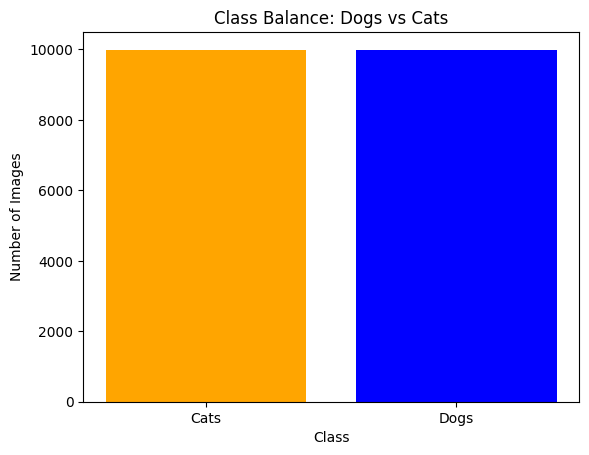

In [ ]:
labels, counts = np.unique(train_data.classes, return_counts=True)

plt.bar(labels, counts, color=['orange', 'blue'])
plt.xticks(labels, ['Cats', 'Dogs'])
plt.title('Class Balance: Dogs vs Cats')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.show() #We have balanced classes

In [ ]:

#model = Sequential([
#    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)), # starting my firs conv block with 32 filter which are 3,3 ,and of course our input is 64x64 ,and we have 3 chanels for RGB
#    MaxPooling2D(pool_size=(2, 2)),                                 # Using max pooling which downs our dimensionality and takes the max value of our 2,2 blocks
#    Conv2D(64, (3, 3), activation='relu'), # 64 FIlters
#    MaxPooling2D(pool_size=(2, 2)),
#    Conv2D(128, (3, 3), activation='relu'),  # 128 filters
#    MaxPooling2D(pool_size=(2, 2)),
#    Flatten(), # Flattening our array to 1D so we can start our
#    Dense(128, activation='relu'),
#    Dropout(0.5), #Regulazation so we dont overfitt
#    Dense(1, activation='sigmoid') # Here i am using sigmoid which is for binary either is class 0 or class 1
#])

model = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D(2, 2),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       401,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 406,625 (1.55 MB)

 Trainable params: 406,625 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss='binary_crossentropy', # binary because we have binary problem
              optimizer='adam',    #Using standard optimizer
              metrics=['accuracy'])


epochs = 7 # Defining number of epochs on which our model is going to train


history = model.fit( #Fiting our model with data
    train_data,
    epochs=epochs,
    steps_per_epoch=32,   # So this is the parametar i found so my training would be faster ,this parametars basicly limits our images per epoch basicly batch size times steps per epoch
                          #which means we heave 60x64 images per epoch
    validation_steps=10, # This is the same thing but for the validation 15x64
    validation_data=val_data
)

Epoch 1/7
32/32 ━━━━━━━━━━━━━━━━━━━━ 344s 11s/step - accuracy: 0.5288 - loss: 0.6930 - val_accuracy: 0.5672 - val_loss: 0.6825
Epoch 2/7
32/32 ━━━━━━━━━━━━━━━━━━━━ 273s 9s/step - accuracy: 0.5688 - loss: 0.6811 - val_accuracy: 0.6250 - val_loss: 0.6700
Epoch 3/7
32/32 ━━━━━━━━━━━━━━━━━━━━ 228s 7s/step - accuracy: 0.5898 - loss: 0.6686 - val_accuracy: 0.6656 - val_loss: 0.6597
Epoch 4/7
32/32 ━━━━━━━━━━━━━━━━━━━━ 192s 6s/step - accuracy: 0.6132 - loss: 0.6541 - val_accuracy: 0.6438 - val_loss: 0.6312
Epoch 5/7
32/32 ━━━━━━━━━━━━━━━━━━━━ 156s 5s/step - accuracy: 0.6606 - loss: 0.6194 - val_accuracy: 0.6906 - val_loss: 0.6148
Epoch 6/7
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6730 - loss: 0.6092

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


32/32 ━━━━━━━━━━━━━━━━━━━━ 141s 5s/step - accuracy: 0.6548 - loss: 0.6228 - val_accuracy: 0.6734 - val_loss: 0.5948
Epoch 7/7
32/32 ━━━━━━━━━━━━━━━━━━━━ 125s 4s/step - accuracy: 0.6758 - loss: 0.6037 - val_accuracy: 0.6906 - val_loss: 0.5939


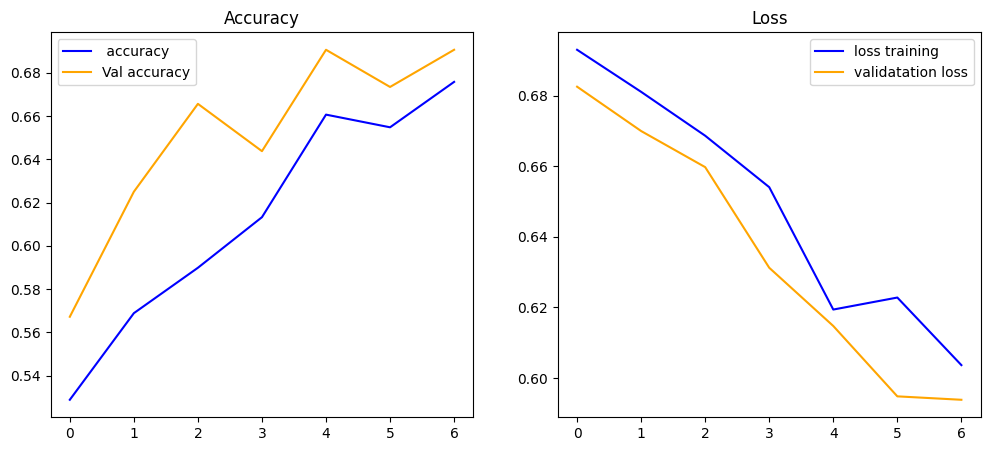

In [ ]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(history.history['accuracy'], label=' accuracy', color='blue')
ax1.plot(history.history['val_accuracy'], label='Val accuracy', color='orange')
ax1.set_title('Accuracy')

ax1.legend()

ax2.plot(history.history['loss'], label='loss training', color='blue')
ax2.plot(history.history['val_loss'], label='validatation loss', color='orange')
ax2.set_title('Loss')

ax2.legend()

plt.show()

In [ ]:
small_df = '/content/drive/MyDrive/DeepLearning /PETIMAGESSMALL'

In [ ]:
IMAGE_SIZE = (128, 128)
BATCH_SIZE = 64

train_data = datagen.flow_from_directory(
    small_df,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'    )


val_data = datagen.flow_from_directory(
    small_df,
    target_size=(128, 128),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

Found 4000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [ ]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

history = model.fit(
    train_data,
    validation_data= val_data,
    epochs=7)

Epoch 1/7
63/63 ━━━━━━━━━━━━━━━━━━━━ 1256s 20s/step - accuracy: 0.5360 - loss: 0.6916 - val_accuracy: 0.6100 - val_loss: 0.6563
Epoch 2/7
63/63 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.6497 - loss: 0.6300 - val_accuracy: 0.6250 - val_loss: 0.6409
Epoch 3/7
63/63 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.6805 - loss: 0.5953 - val_accuracy: 0.6480 - val_loss: 0.6154
Epoch 4/7
63/63 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.6902 - loss: 0.5895 - val_accuracy: 0.7120 - val_loss: 0.5578
Epoch 5/7
63/63 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.7115 - loss: 0.5652 - val_accuracy: 0.7140 - val_loss: 0.5566
Epoch 6/7
63/63 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.7243 - loss: 0.5344 - val_accuracy: 0.7020 - val_loss: 0.5668
Epoch 7/7
63/63 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.7240 - loss: 0.5390 - val_accuracy: 0.7470 - val_loss: 0.5152


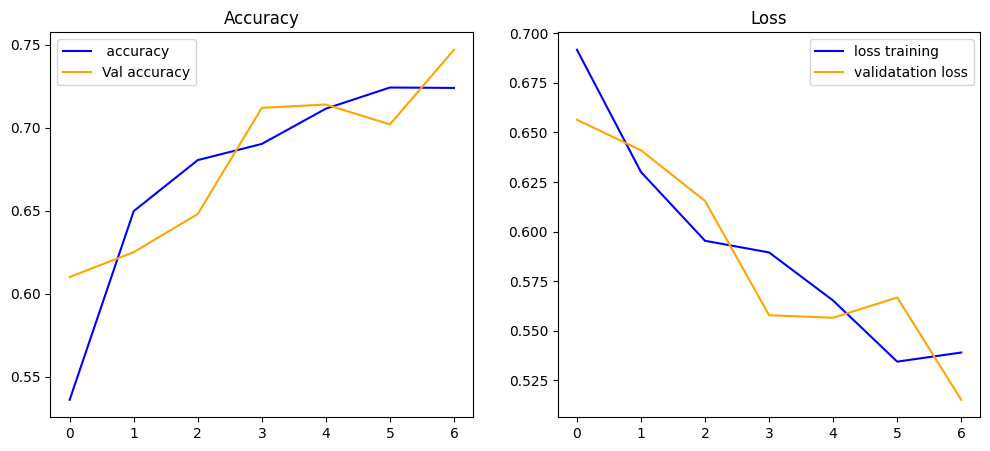

In [ ]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(history.history['accuracy'], label=' accuracy', color='blue')
ax1.plot(history.history['val_accuracy'], label='Val accuracy', color='orange')
ax1.set_title('Accuracy')

ax1.legend()

ax2.plot(history.history['loss'], label='loss training', color='blue')
ax2.plot(history.history['val_loss'], label='validatation loss', color='orange')
ax2.set_title('Loss')

ax2.legend()

plt.show()

In [ ]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(input_shape=(128,128,3), include_top=False, weights='imagenet')

model = Sequential([
    base_model,
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5,
    batch_size=128,
    callbacks=[early_stop]
)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 187s 3s/step - accuracy: 0.8752 - loss: 0.3355 - val_accuracy: 0.8320 - val_loss: 2.3492
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 169s 3s/step - accuracy: 0.9190 - loss: 0.2250 - val_accuracy: 0.7980 - val_loss: 1.1444
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 167s 3s/step - accuracy: 0.9330 - loss: 0.1821 - val_accuracy: 0.7850 - val_loss: 2.0065
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 167s 3s/step - accuracy: 0.9470 - loss: 0.1519 - val_accuracy: 0.8060 - val_loss: 1.6016


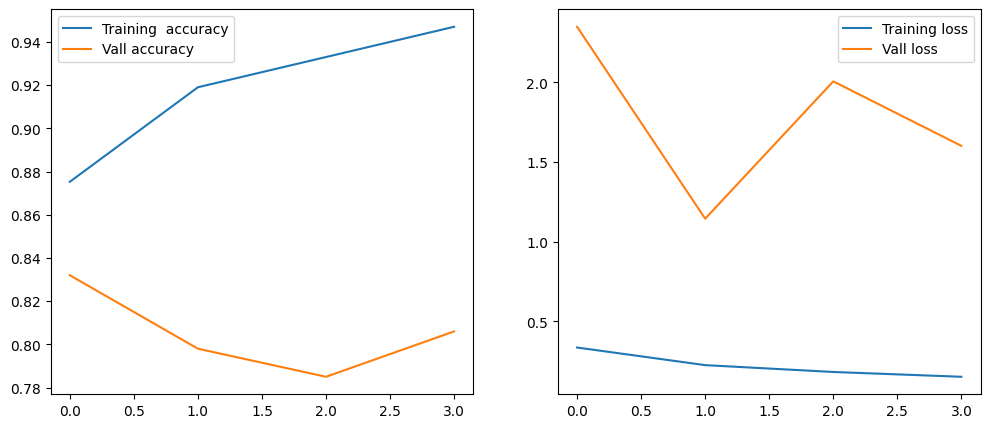

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))


ax1.plot(history.history['accuracy'], label='Training  accuracy')
ax1.plot(history.history['val_accuracy'], label='Vall accuracy')

ax1.legend()


ax2.plot(history.history['loss'], label='Training loss')
ax2.plot(history.history['val_loss'], label='Vall loss')

ax2.legend()

plt.show()